# MusicPulse — journal d'exploration, nettoyage et analyse

Ce notebook est volontairement **détaillé et non réduit à un script final** : il conserve les contrôles intermédiaires, les problèmes observés et les décisions prises. Il répond aux trois attentes du livrable :

1. identifier les problèmes rencontrés dans les données ;
2. montrer comment les données ont été explorées et nettoyées ;
3. présenter un enchaînement **ETL → Query → Plot** répondant à des questions métier.

Le travail est exécuté sur l'échantillon versionné. Les scripts du projet appliquent la même logique au dataset Kaggle complet en traitant l'historique par chunks.

## Questions métier

- Quels morceaux concentrent le plus d'écoutes ?
- Quels artistes cumulent le plus d'écoutes ?
- Quels genres dominent l'échantillon ?
- Les écoutes sont-elles réparties équitablement ou suivent-elles une longue traîne ?

Ces résultats servent ensuite à préparer les documents Firestore et les classements Redis.

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

ROOT = Path.cwd()
if not (ROOT / 'data' / 'sample').exists():
    ROOT = ROOT.parent

TRACKS_PATH = ROOT / 'data' / 'sample' / 'tracks_sample.csv'
HISTORY_PATH = ROOT / 'data' / 'sample' / 'listening_history_sample.csv'

tracks_raw = pd.read_csv(TRACKS_PATH)
history_raw = pd.read_csv(HISTORY_PATH)

print('Catalogue brut :', tracks_raw.shape)
print('Historique brut :', history_raw.shape)

Catalogue brut : (2000, 21)
Historique brut : (100000, 3)


## 1 — Exploration des données brutes

On commence sans modifier les DataFrames. L'objectif est de conserver une photographie des fichiers reçus et de vérifier les colonnes, les types, les valeurs manquantes, les doublons et l'intégrité entre les deux fichiers.

In [10]:
display(tracks_raw.head(3))
display(history_raw.head(3))

schema = pd.DataFrame({
    'type_catalogue': tracks_raw.dtypes.astype(str),
    'valeurs_manquantes': tracks_raw.isna().sum(),
    'valeurs_uniques': tracks_raw.nunique(dropna=True),
})
display(schema)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRNNGMK128F423F034,Where Is My Mind?,Pixies,https://p.scdn.co/mp3-preview/d4a375a9c19d4ea8...,0DJU6KGwdkxEPCy3BZ3UZY,"rock, alternative, indie, alternative_rock, in...",Rock,2005,230093,0.514,0.435,4,-13.517,1,0.0353,0.007800,0.000859,0.0802,0.212,82.104,4
1,TRAALAH128E078234A,Bitter Sweet Symphony,The Verve,https://p.scdn.co/mp3-preview/3debe861147de110...,0jLnevC3Vn34qVWrAa4X6x,"rock, alternative, indie, pop, alternative_roc...",NaN,1999,358333,0.383,0.907,9,-5.409,1,0.0405,0.031300,0.000000,0.3470,0.514,171.052,4
2,TRQFICK128F92F5190,Toxicity,System of a Down,https://p.scdn.co/mp3-preview/89e93c71655e8157...,0snQkGI5qnAmohLE7jTsTn,"rock, alternative, metal, alternative_rock, ha...",NaN,2001,218933,0.413,0.873,8,-4.151,1,0.0536,0.000264,0.002490,0.2040,0.480,116.680,3


,track_id,user_id,playcount
0,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRGRDEC128F423C07D,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


,type_catalogue,valeurs_manquantes,valeurs_uniques
track_id,object,0,2000
name,object,0,2000
artist,object,0,891
spotify_preview_url,object,0,2000
spotify_id,object,0,2000
tags,object,18,1553
genre,object,724,15
year,int64,0,51
duration_ms,int64,0,1872
danceability,float64,0,667


### Problèmes recherchés

- genres et tags manquants ;
- chaînes vides ou espaces parasites ;
- doublons de `track_id` ;
- types numériques lus comme du texte ;
- années, durées ou caractéristiques audio incohérentes ;
- nombres d'écoutes nuls ou négatifs ;
- interactions qui référencent un morceau absent du catalogue ;
- historique trop volumineux pour être chargé en une fois dans le cas complet.

In [11]:
missing = (tracks_raw.isna().mean() * 100).sort_values(ascending=False)
duplicates_tracks = tracks_raw.duplicated('track_id').sum()
duplicates_interactions = history_raw.duplicated(['user_id', 'track_id']).sum()
invalid_playcounts = pd.to_numeric(history_raw['playcount'], errors='coerce').le(0).sum()
orphan_interactions = (~history_raw['track_id'].isin(tracks_raw['track_id'])).sum()

quality_report = pd.Series({
    'lignes catalogue': len(tracks_raw),
    'lignes historique': len(history_raw),
    'track_id dupliqués': int(duplicates_tracks),
    'couples utilisateur-morceau dupliqués': int(duplicates_interactions),
    'playcount <= 0 ou invalide': int(invalid_playcounts),
    'interactions sans morceau correspondant': int(orphan_interactions),
})
display(quality_report.to_frame('valeur'))
display(missing.head(12).to_frame('% manquant'))

,valeur
lignes catalogue,2000
lignes historique,100000
track_id dupliqués,0
couples utilisateur-morceau dupliqués,0
playcount <= 0 ou invalide,0
interactions sans morceau correspondant,0


,% manquant
genre,36.2
tags,0.9
artist,0.0
name,0.0
track_id,0.0
spotify_id,0.0
spotify_preview_url,0.0
year,0.0
duration_ms,0.0
danceability,0.0


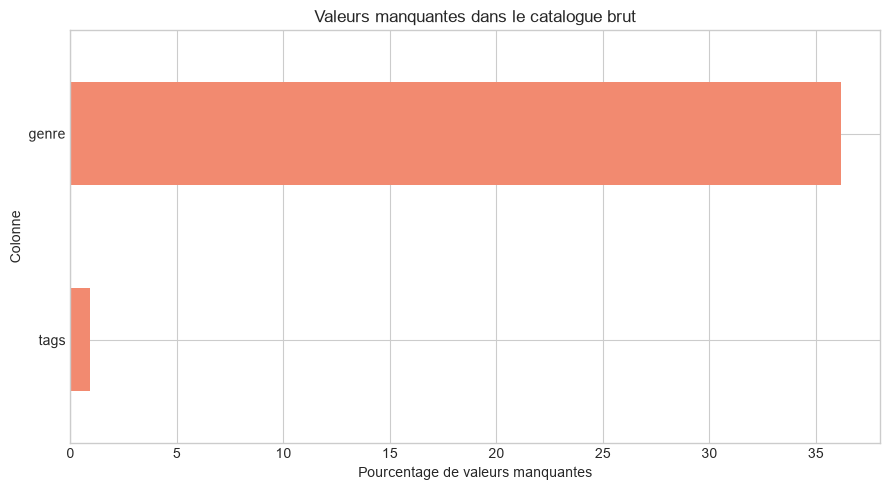

In [12]:
missing[missing > 0].sort_values().plot.barh(figsize=(9, 5), color='#F28A70')
plt.title('Valeurs manquantes dans le catalogue brut')
plt.xlabel('Pourcentage de valeurs manquantes')
plt.ylabel('Colonne')
plt.tight_layout();

### Constats intermédiaires

Le principal défaut concerne le genre : il n'est pas toujours renseigné alors que les tags contiennent souvent une information exploitable. Les tags sont multivalués et séparés par des virgules. L'historique contient seulement les identifiants utilisateur/morceau et le nombre d'écoutes : un ETL est donc nécessaire pour l'enrichir avec le titre, l'artiste et le genre.

Dans le dataset complet, les millions d'interactions imposent une lecture par chunks. L'échantillon reste suffisamment petit pour rendre les étapes visibles dans ce notebook.

## 2 — Nettoyage et justification des choix

Les données brutes ne sont jamais écrasées : les transformations sont appliquées à des copies `tracks_clean` et `history_clean`.

In [13]:
tracks_clean = tracks_raw.copy()

# 1. Uniformiser les chaînes et convertir les chaînes vides en valeurs manquantes.
text_columns = tracks_clean.select_dtypes(include='object').columns
for column in text_columns:
    tracks_clean[column] = (
        tracks_clean[column].astype('string').str.strip().replace('', pd.NA)
    )

# 2. Un document Firestore doit avoir un identifiant unique.
tracks_clean = tracks_clean.dropna(subset=['track_id'])
tracks_clean = tracks_clean.drop_duplicates(subset=['track_id'], keep='first')

# 3. Convertir explicitement les colonnes numériques.
integer_columns = ['year', 'duration_ms', 'key', 'mode', 'time_signature']
audio_columns = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
for column in integer_columns + audio_columns:
    if column in tracks_clean:
        tracks_clean[column] = pd.to_numeric(tracks_clean[column], errors='coerce')

# 4. Le genre principal utilise le genre déclaré, sinon le premier tag.
fallback_genre = (
    tracks_clean['tags'].fillna('Unknown').str.split(',').str[0].str.strip()
)
tracks_clean['primary_genre'] = (
    tracks_clean['genre'].fillna(fallback_genre).fillna('Unknown').str.strip()
)

# 5. Champs dénormalisés utiles aux recherches Firestore.
tracks_clean['name_normalized'] = tracks_clean['name'].str.lower()
tracks_clean['artist_normalized'] = tracks_clean['artist'].str.lower()

display(tracks_clean[['track_id', 'name', 'artist', 'genre', 'tags', 'primary_genre']].head())

,track_id,name,artist,genre,tags,primary_genre
0,TRNNGMK128F423F034,Where Is My Mind?,Pixies,Rock,"rock, alternative, indie, alternative_rock, in...",Rock
1,TRAALAH128E078234A,Bitter Sweet Symphony,The Verve,<NA>,"rock, alternative, indie, pop, alternative_roc...",rock
2,TRQFICK128F92F5190,Toxicity,System of a Down,<NA>,"rock, alternative, metal, alternative_rock, ha...",rock
3,TRPFYYL128F92F7144,Float On,Modest Mouse,Rock,"rock, alternative, indie, alternative_rock, in...",Rock
4,TRFWGOJ128E0780C8B,In My Place,Coldplay,Rock,"rock, alternative, indie, pop, alternative_roc...",Rock


In [14]:
history_clean = history_raw.copy()
history_clean['user_id'] = history_clean['user_id'].astype('string').str.strip()
history_clean['track_id'] = history_clean['track_id'].astype('string').str.strip()
history_clean['playcount'] = pd.to_numeric(history_clean['playcount'], errors='coerce')

# Retirer les lignes inutilisables puis regrouper les doublons logiques.
history_clean = history_clean.dropna(subset=['user_id', 'track_id', 'playcount'])
history_clean = history_clean[history_clean['playcount'] > 0]
history_clean = history_clean[history_clean['track_id'].isin(tracks_clean['track_id'])]
history_clean = (
    history_clean.groupby(['user_id', 'track_id'], as_index=False)['playcount'].sum()
)

print('Historique nettoyé :', history_clean.shape)
display(history_clean.head())

Historique nettoyé : (100000, 3)


,user_id,track_id,playcount
0,000b474f815bcff17a4bc9ce5324f9352dafe07d,TRRKODA128F146DE22,2
1,000b474f815bcff17a4bc9ce5324f9352dafe07d,TRWSBNB128F4276F7F,4
2,000b4e4134d5f77d7608fbf86fb3e1adac4478a8,TRJZEBT128F92EBF9B,16
3,000b4e4134d5f77d7608fbf86fb3e1adac4478a8,TRRZVKM128F14A94E3,2
4,000ebc858861aca26bac9b49f650ed424cf882fc,TRARVWA128E0782562,1


In [15]:
audit = pd.DataFrame({
    'avant': [
        len(tracks_raw), len(history_raw), tracks_raw['genre'].isna().sum(),
        tracks_raw.duplicated('track_id').sum(),
        history_raw.duplicated(['user_id', 'track_id']).sum(),
    ],
    'après': [
        len(tracks_clean), len(history_clean), tracks_clean['primary_genre'].isna().sum(),
        tracks_clean.duplicated('track_id').sum(),
        history_clean.duplicated(['user_id', 'track_id']).sum(),
    ],
}, index=[
    'lignes catalogue', 'lignes historique', 'genres exploitables manquants',
    'track_id dupliqués', 'interactions dupliquées',
])
display(audit)

,avant,après
lignes catalogue,2000,2000
lignes historique,100000,100000
genres exploitables manquants,724,0
track_id dupliqués,0,0
interactions dupliquées,0,0


## 3 — ETL vers Firestore et Redis

- **Extract** : lecture des deux CSV ;
- **Transform** : nettoyage, typage, genre de remplacement et agrégations ;
- **Load Firestore** : un document dénormalisé par morceau ;
- **Load Redis** : agrégats de classement et structures à accès rapide.

In [16]:
# Enrichissement de l'historique : équivalent d'une jointure réalisée pendant l'ETL.
catalogue_columns = ['track_id', 'name', 'artist', 'primary_genre']
listens = history_clean.merge(
    tracks_clean[catalogue_columns], on='track_id', how='left', validate='many_to_one'
)

coverage = listens['name'].notna().mean() * 100
print(f'Interactions enrichies avec un morceau : {coverage:.2f} %')
display(listens.head())

Interactions enrichies avec un morceau : 100.00 %


,user_id,track_id,playcount,name,artist,primary_genre
0,000b474f815bcff17a4bc9ce5324f9352dafe07d,TRRKODA128F146DE22,2,Robot Rock,Daft Punk,Electronic
1,000b474f815bcff17a4bc9ce5324f9352dafe07d,TRWSBNB128F4276F7F,4,Secret Crowds,Angels & Airwaves,Rock
2,000b4e4134d5f77d7608fbf86fb3e1adac4478a8,TRJZEBT128F92EBF9B,16,Half a Person,The Smiths,Rock
3,000b4e4134d5f77d7608fbf86fb3e1adac4478a8,TRRZVKM128F14A94E3,2,Cemetry Gates,The Smiths,Rock
4,000ebc858861aca26bac9b49f650ed424cf882fc,TRARVWA128E0782562,1,Buffalo Stance,Neneh Cherry,pop


In [17]:
# Exemple de documents prêts pour la collection Firestore `tracks`.
firestore_fields = [
    'track_id', 'name', 'artist', 'primary_genre', 'year', 'energy',
    'danceability', 'tempo', 'name_normalized', 'artist_normalized'
]
firestore_documents = (
    tracks_clean[[c for c in firestore_fields if c in tracks_clean.columns]]
    .where(pd.notna(tracks_clean), None)
    .to_dict(orient='records')
)
firestore_documents[:2]

[{'track_id': 'TRNNGMK128F423F034',
  'name': 'Where Is My Mind?',
  'artist': 'Pixies',
  'primary_genre': 'Rock',
  'year': 2005,
  'energy': 0.435,
  'danceability': 0.514,
  'tempo': 82.104,
  'name_normalized': 'where is my mind?',
  'artist_normalized': 'pixies'},
 {'track_id': 'TRAALAH128E078234A',
  'name': 'Bitter Sweet Symphony',
  'artist': 'The Verve',
  'primary_genre': 'rock',
  'year': 1999,
  'energy': 0.907,
  'danceability': 0.383,
  'tempo': 171.052,
  'name_normalized': 'bitter sweet symphony',
  'artist_normalized': 'the verve'}]

In [18]:
# Agrégats prêts pour les Sorted Sets Redis.
redis_track_ranking = (
    listens.groupby('track_id', as_index=False)['playcount'].sum()
    .sort_values('playcount', ascending=False)
)
redis_artist_ranking = (
    listens.groupby('artist', as_index=False)['playcount'].sum()
    .sort_values('playcount', ascending=False)
)

print('Exemple de clé cache :', f"track:{tracks_clean.iloc[0]['track_id']}:cache")
print('Exemple de Sorted Set : ranking:tracks:global')
display(redis_track_ranking.head())

Exemple de clé cache : track:TRNNGMK128F423F034:cache
Exemple de Sorted Set : ranking:tracks:global


,track_id,playcount
1128,TRONYHY128F92C9D11,10514
1552,TRUFTBY128F93450B8,2184
1970,TRZNAHL128F9327D5A,1873
1206,TRPGPDK12903CCC651,1803
1204,TRPFYYL128F92F7144,1618


## 4 — Query & Plot : réponses aux questions métier

,track_id,name,artist,playcount
1128,TRONYHY128F92C9D11,Revelry,Kings of Leon,10514
1552,TRUFTBY128F93450B8,Alejandro,Lady Gaga,2184
1970,TRZNAHL128F9327D5A,Gears,Miss May I,1873
1206,TRPGPDK12903CCC651,Bring Me To Life,Katherine Jenkins,1803
1204,TRPFYYL128F92F7144,Float On,Modest Mouse,1618
1123,TROMKCG128F9320C09,Uprising,Sabaton,1574
220,TRCPXID128F92D5D3C,Halo,Depeche Mode,1555
57,TRAOIAH128F92F707B,It Was A Good Day,Ice Cube,1538
499,TRGCHLH12903CB7352,Party In The U.S.A.,The Barden Bellas,1531
1861,TRXWAZC128F9314B3E,Heartbreak Warfare,John Mayer,1506


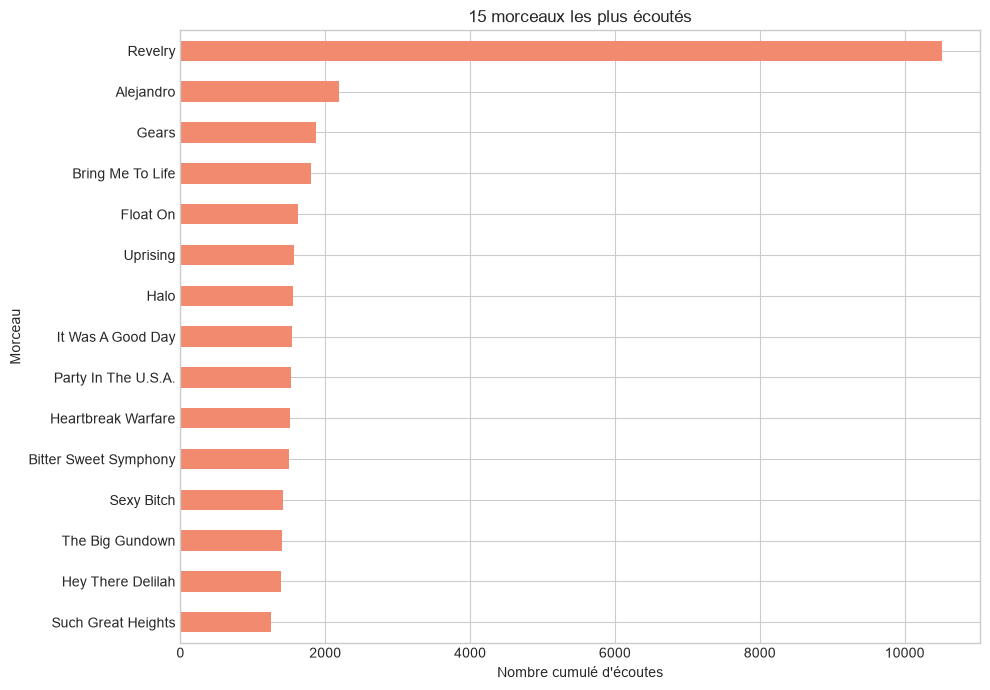

In [19]:
# Question 1 : quels morceaux concentrent le plus d'écoutes ?
top_tracks = (
    listens.groupby(['track_id', 'name', 'artist'], as_index=False)['playcount'].sum()
    .nlargest(15, 'playcount')
)
display(top_tracks)

top_tracks.sort_values('playcount').plot.barh(
    x='name', y='playcount', figsize=(10, 7), legend=False, color='#F28A70'
)
plt.title('15 morceaux les plus écoutés')
plt.xlabel("Nombre cumulé d'écoutes")
plt.ylabel('Morceau')
plt.tight_layout();

,artist,playcount
441,Kings of Leon,11440
743,The Black Keys,6011
421,Justin Bieber,4017
176,Coldplay,3368
791,The Postal Service,3108
376,Jack Johnson,3066
520,Metric,2955
623,Radiohead,2851
535,Modest Mouse,2811
453,Lady Gaga,2810


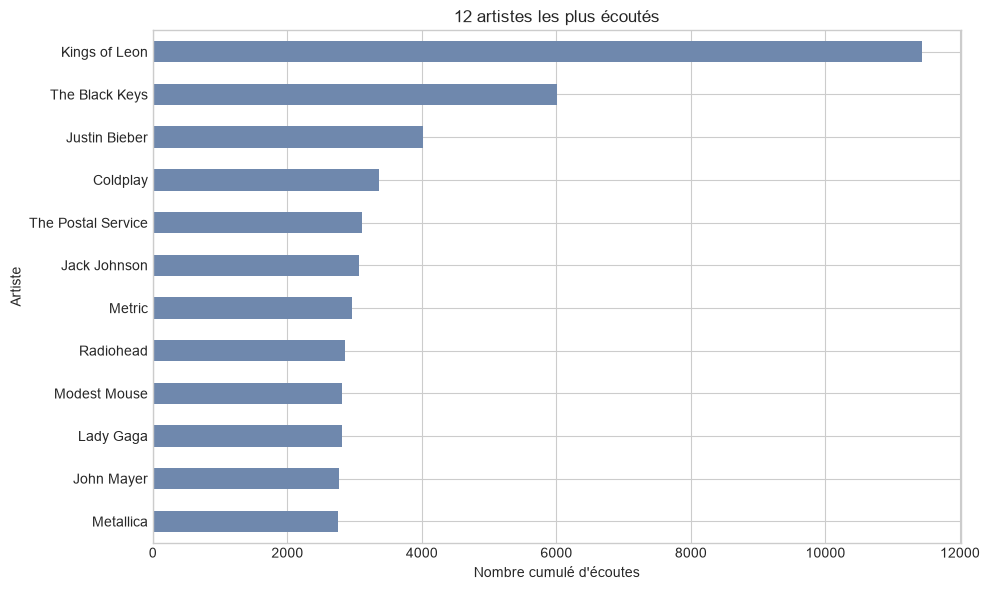

In [20]:
# Question 2 : quels artistes cumulent le plus d'écoutes ?
top_artists = (
    listens.groupby('artist', as_index=False)['playcount'].sum()
    .nlargest(12, 'playcount')
)
display(top_artists)

top_artists.sort_values('playcount').plot.barh(
    x='artist', y='playcount', figsize=(10, 6), legend=False, color='#6F88AD'
)
plt.title('12 artistes les plus écoutés')
plt.xlabel("Nombre cumulé d'écoutes")
plt.ylabel('Artiste')
plt.tight_layout();

,primary_genre,playcount
17,Rock,106882
65,rock,28709
12,Pop,20409
6,Electronic,19419
34,electronic,19134
14,Rap,12006
55,pop,9828
5,Country,9191
43,indie,6895
21,alternative,6577


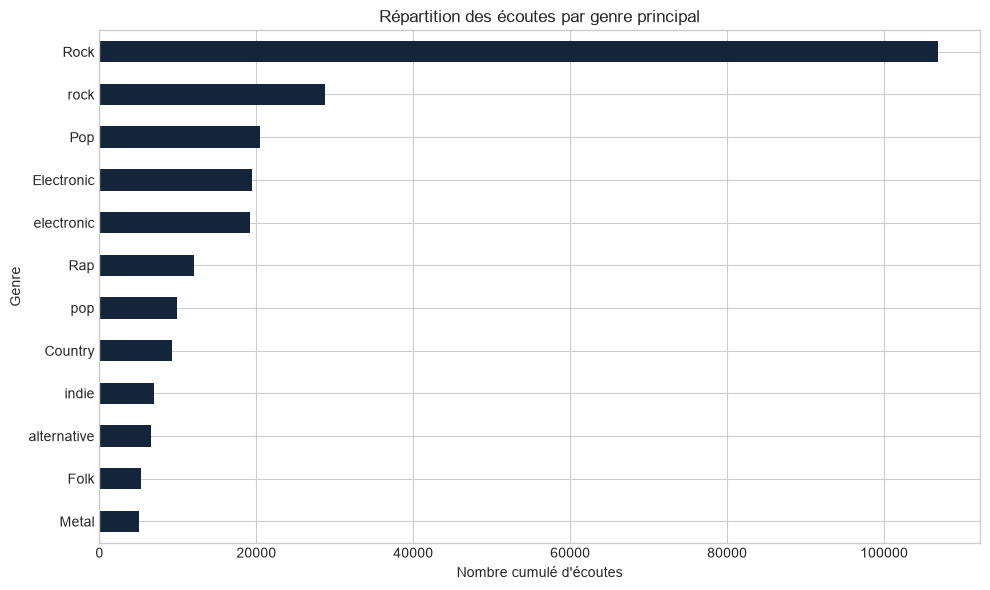

In [21]:
# Question 3 : quels genres dominent l'échantillon ?
top_genres = (
    listens.groupby('primary_genre', as_index=False)['playcount'].sum()
    .nlargest(12, 'playcount')
)
display(top_genres)

top_genres.sort_values('playcount').plot.barh(
    x='primary_genre', y='playcount', figsize=(10, 6), legend=False, color='#14243A'
)
plt.title('Répartition des écoutes par genre principal')
plt.xlabel("Nombre cumulé d'écoutes")
plt.ylabel('Genre')
plt.tight_layout();

Les 10 % de morceaux les plus écoutés concentrent 38.9% des écoutes.


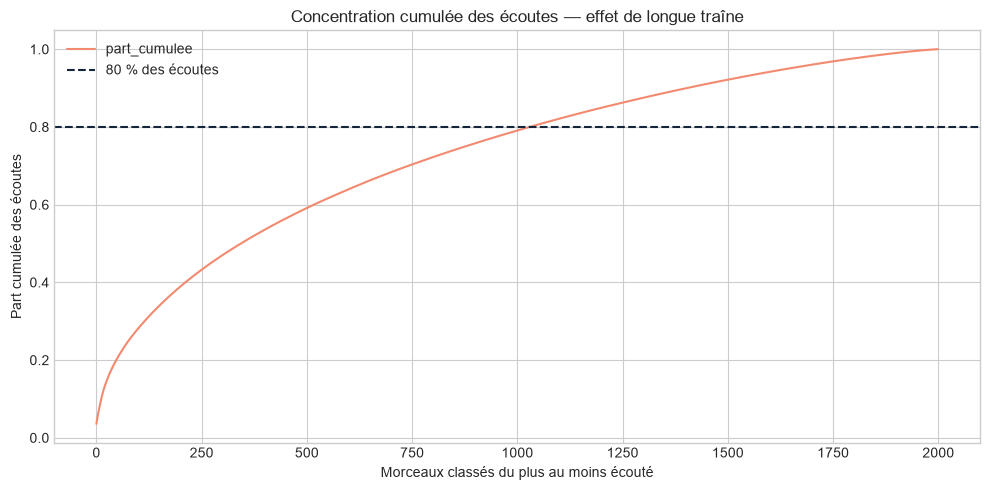

In [22]:
# Question 4 : observe-t-on une longue traîne ?
distribution = redis_track_ranking.sort_values('playcount', ascending=False).reset_index(drop=True)
distribution['part_cumulee'] = distribution['playcount'].cumsum() / distribution['playcount'].sum()
top_10_percent_count = max(1, int(np.ceil(len(distribution) * 0.10)))
top_10_percent_share = distribution.head(top_10_percent_count)['playcount'].sum() / distribution['playcount'].sum()
print(f"Les 10 % de morceaux les plus écoutés concentrent {top_10_percent_share:.1%} des écoutes.")

distribution['part_cumulee'].plot(figsize=(10, 5), color='#F28A70')
plt.axhline(0.80, color='#14243A', linestyle='--', label='80 % des écoutes')
plt.title('Concentration cumulée des écoutes — effet de longue traîne')
plt.xlabel('Morceaux classés du plus au moins écouté')
plt.ylabel('Part cumulée des écoutes')
plt.legend()
plt.tight_layout();

## 5 — Conclusions, limites et décisions techniques

### Ce que l'exploration a changé

- le champ `primary_genre` compense les genres manquants avec le premier tag ;
- les documents Firestore sont dénormalisés pour éviter les jointures à la lecture ;
- les classements sont précalculés pour être chargés dans des Sorted Sets Redis ;
- l'historique complet doit être traité par chunks de 500 000 lignes ;
- le cache Redis reçoit un TTL pour limiter les données anciennes.

### Limites

L'échantillon favorise les morceaux les plus écoutés : les résultats décrivent donc la démonstration et non toute la population musicale. Les genres reconstruits depuis les tags restent approximatifs. Enfin, les graphiques sont calculés avec pandas ; Firestore conserve les documents durables et Redis sert les classements rapides dans l'application.